# NumPy Aggregations: Min, Max, and Everything In Between

When faced with a large dataset, the first step is almost always to compute **summary statistics** — values that describe the shape and spread of the data.

Common summary statistics include:
- **Mean** and **standard deviation** — describe the typical value and spread
- **Sum, min, max** — total, smallest, and largest values
- **Median and percentiles** — describe where values fall in the distribution

NumPy provides fast built-in aggregation functions for all of these. Because they run in compiled C code rather than interpreted Python, **NumPy aggregations are dramatically faster** than Python's built-in equivalents — especially on large arrays.

Throughout this notebook we will demonstrate this using a **UK secondary school student scores dataset**.

In [1]:
import numpy as np   # core library for fast numerical operations

## Part 1 - NumPy vs Python: Speed Comparison

### Summing an Array

We start with a simple demonstration: creating a random array and summing it two ways — using Python's built-in `sum()` and using `np.sum()`.

In [ ]:
analysis.py
function
variables
classes 

In [3]:
# Create an array of 100 random floats between 0 and 1
L = np.random.random(100)
print(L)

[0.12779482 0.29139286 0.43747363 0.12158605 0.3770012  0.19091855
 0.89910386 0.83902822 0.8372033  0.60757794 0.41557882 0.42232859
 0.77162601 0.63454457 0.87342865 0.90081278 0.14261933 0.54543431
 0.70496586 0.82050873 0.74007307 0.92929127 0.08422168 0.56308229
 0.72000726 0.52410128 0.99329782 0.56322972 0.91826648 0.94940748
 0.34311765 0.58839839 0.24151237 0.93181967 0.37921608 0.70272967
 0.32629137 0.72712296 0.90982966 0.17804046 0.14553356 0.33491069
 0.76966343 0.10167611 0.87949839 0.3071024  0.03311052 0.87366375
 0.35038964 0.70504401 0.75363828 0.61367022 0.12833923 0.70844024
 0.07938886 0.19526475 0.41598579 0.12306692 0.05158915 0.33857013
 0.21844751 0.17798481 0.88412386 0.55487416 0.35815706 0.26081379
 0.28054585 0.31618102 0.00783926 0.60076971 0.5791643  0.06386077
 0.20769285 0.67286213 0.76113921 0.49697135 0.38938262 0.69039522
 0.93672111 0.72876608 0.66987471 0.97789819 0.66228782 0.7581276
 0.95774746 0.38354412 0.67585558 0.54021778 0.62957402 0.62729

In [4]:
# Both produce the same result — but via very different routes
print('Python sum :', sum(L))      # Python's built-in: loops through each element
print('NumPy sum  :', np.sum(L))   # NumPy: runs compiled C code — much faster

Python sum : 53.29122337916834
NumPy sum  : 53.29122337916834


In [5]:
# The speed difference becomes significant on large arrays
# Create 1 million random values to make the gap visible
big_array = np.random.rand(1_000_000)

%timeit sum(big_array)     # Python's built-in sum — loops in Python
%timeit np.sum(big_array)  # NumPy sum — runs in compiled C code

29.5 ms ± 89.3 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
132 μs ± 4.19 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


> **Note:** `np.sum` is not identical to Python's `sum`. `np.sum` is aware of **multiple array dimensions** (rows and columns), while `sum` is not. Always use `np.sum` on NumPy arrays.

### Minimum and Maximum

Python has built-in `min()` and `max()` functions, but NumPy's equivalents are faster and dimension-aware.

In [5]:
# Python built-ins — correct result, but slow on large arrays
print('Python min:', min(big_array), '  max:', max(big_array))

Python min: 1.5132720666555244e-06   max: 0.9999987935148303


In [6]:
# NumPy equivalents — same result, compiled C speed
print('NumPy  min:', np.min(big_array), '  max:', np.max(big_array))

NumPy  min: 1.5132720666555244e-06   max: 0.9999987935148303


In [7]:
# Speed comparison for min and max on 1 million values
%timeit min(big_array)    # Python built-in
%timeit np.min(big_array) # NumPy — substantially faster

19.6 ms ± 357 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
70.5 μs ± 735 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [6]:
# Shorthand: call aggregations directly as methods on the array object
# This is the most common and readable style in practice
print('min:', big_array.min())
print('max:', big_array.max())
print('sum:', big_array.sum())

min: 1.2861293096078086e-06
max: 0.9999998952362403
sum: 499714.77688335825


> **Rule:** Whenever working with NumPy arrays, always use NumPy aggregations — either `np.sum(arr)` or `arr.sum()`. Both are equivalent and both are fast.

## Part 2 - Multi-Dimensional Aggregates

NumPy's aggregation functions accept an **`axis`** argument that controls which dimension is collapsed.

- `axis=0` — collapse **down the rows** → one result per **column**
- `axis=1` — collapse **across the columns** → one result per **row**

This maps directly to school data: rows = students, columns = subjects.

In [7]:
# Create a small 3x4 matrix to demonstrate axis behaviour
M = np.random.random((3, 4))
print('Matrix M (3 rows, 4 columns):')
M.round(3)

Matrix M (3 rows, 4 columns):


array([[0.127, 0.992, 0.744, 0.167],
       [0.48 , 0.582, 0.117, 0.347],
       [0.768, 0.022, 0.982, 0.925]])

In [8]:
# Default: aggregate over the entire array → one scalar result
print('Sum of all elements:', M.sum())

Sum of all elements: 6.252383514062554


In [10]:
# axis=0 — collapse DOWN the rows — produces one value per COLUMN
# Equivalent to: "minimum value in each column"
print('Min per column (axis=0):', M.min(axis=0))

Min per column (axis=0): [0.12732102 0.02219625 0.11692658 0.16655349]


In [11]:
# axis=1 — collapse ACROSS the columns — produces one value per ROW
# Equivalent to: "maximum value in each row"
print('Max per row (axis=1):', M.max(axis=1))

Max per row (axis=1): [0.99150105 0.58219657 0.98186739]


## Part 3 - Practical Example: Student Subject Scores

Aggregates become most useful on real data. We will use a dataset of **42 UK secondary school students** with scores in three subjects: Maths, English, and Science.

We use pandas to load the CSV, then extract NumPy arrays for all the calculations.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')   # clean plot background

In [27]:
# Load the student scores CSV into a pandas DataFrame
data = pd.read_csv('student_scores.csv')

# print(f'Dataset: {data.shape[0]} students, {data.shape[1]} columns')
# data.head()



<class 'pandas.core.series.Series'>


In [29]:
# Extract each subject column as a NumPy array
# np.array() converts the pandas Series to a plain 1D NumPy array
maths   = np.array(data['maths'])
english = np.array(data['english'])
science = np.array(data['science'])

print('Type:', type(maths))         # confirm it is a numpy array
print('Shape:', maths.shape)        # (42,) — 42 values in one dimension
print('First 5 maths scores:', maths[:5])

Type: <class 'numpy.ndarray'>
Shape: (42,)
First 5 maths scores: [73.5 44.9 64.9 34.6 43.4]


### Summary Statistics for Maths Scores

We compute a full set of aggregations on the maths column — mean, standard deviation, min, max, and percentiles.

In [30]:
# Core aggregations on the maths score array
print('=== Maths Score Summary ===')
print(f'Mean score        : {maths.mean():.1f}')   # average score across all students
print(f'Standard deviation: {maths.std():.1f}')    # spread around the mean
print(f'Minimum score     : {maths.min():.1f}')    # lowest score
print(f'Maximum score     : {maths.max():.1f}')    # highest score
print(f'Total score sum   : {maths.sum():.1f}')    # sum of all scores (less common but useful)

=== Maths Score Summary ===
Mean score        : 61.2
Standard deviation: 13.7
Minimum score     : 25.3
Maximum score     : 83.9
Total score sum   : 2571.4


In [33]:
data[data['maths'] == maths.min()]

,student_id,name,year_group,maths,english,science
40,S041,Oscar Dahl,7,25.3,64.6,42.1


In [21]:
# Identify the student with the highest and lowest maths score
# data[...] filters the DataFrame to rows matching the condition
print('Highest maths score:')
data[data['maths'] == maths.max()][['name', 'year_group', 'maths']]

Highest maths score:


,name,year_group,maths
39,Nia Osei,9,83.9


In [34]:
print('\nLowest maths score:')
data[data['maths'] == maths.min()][['name', 'year_group', 'maths']]


Lowest maths score:


,name,year_group,maths
40,Oscar Dahl,7,25.3


In [35]:
# Percentiles — show where scores fall in the distribution
# np.percentile(array, q) returns the value below which q% of scores fall
print('=== Maths Score Percentiles ===')
print(f'25th percentile : {np.percentile(maths, 25):.1f}')   # bottom quarter
print(f'Median (50th)   : {np.median(maths):.1f}')           # middle value
print(f'75th percentile : {np.percentile(maths, 75):.1f}')   # top quarter

=== Maths Score Percentiles ===
25th percentile : 52.6
Median (50th)   : 63.0
75th percentile : 73.1


### Comparing All Three Subjects at Once

We can stack all three subject arrays into a 2D matrix and use the **`axis`** argument to compute per-subject or per-student aggregations in one call.

In [25]:
# Stack the three subject arrays into a (42, 3) matrix
# Each row = one student, each column = one subject
scores = np.column_stack([maths, english, science])

print('Shape:', scores.shape)   # (42 students, 3 subjects)
print('\nFirst 5 rows (maths | english | science):')
scores[:5].round(1)

Shape: (42, 3)

First 5 rows (maths | english | science):


array([[73.5, 66. , 77.1],
       [44.9, 61.4, 71.3],
       [64.9, 66.1, 71.9],
       [34.6, 41.1, 46.4],
       [43.4, 62.4, 81. ]])

In [26]:
# axis=0 — collapse DOWN the rows — one result per SUBJECT (column)
# Equivalent to: "mean score in each subject across all students"
subject_means = scores.mean(axis=0)
print('Mean score per subject (axis=0):')
for subject, mean in zip(['Maths', 'English', 'Science'], subject_means):
    print(f'  {subject:8s}: {mean:.1f}')

Mean score per subject (axis=0):
  Maths   : 61.2
  English : 64.0
  Science : 60.2


In [32]:
# axis=1 — collapse ACROSS the columns — one result per STUDENT (row)
# Equivalent to: "average score across all subjects for each student"
student_means = scores.mean(axis=1)

print('Overall average score per student (first 10):')
for name, avg in zip(data['name'][:10], student_means[:10]):
    print(f'  {name:25s}: {avg:.1f}')

Overall average score per student (first 10):
  Amara Osei               : 72.2
  Ben Carter               : 59.2
  Chloe Davies             : 67.6
  Daniel Mwangi            : 40.7
  Esi Asante               : 62.3
  Finn Murphy              : 57.7
  Grace Liu                : 74.6
  Hassan Ali               : 72.0
  Isla Thompson            : 53.6
  James Okafor             : 56.1


In [28]:
# Full subject comparison — min, mean, max, std for each subject
subjects = ['Maths', 'English', 'Science']
print(f'{"":<10} {"Min":>6} {"Mean":>6} {"Max":>6} {"Std":>6}')
print('-' * 38)
for i, subj in enumerate(subjects):
    col = scores[:, i]   # select column i — all students for this subject
    print(f'{subj:<10} {col.min():>6.1f} {col.mean():>6.1f} {col.max():>6.1f} {col.std():>6.1f}')

              Min   Mean    Max    Std
--------------------------------------
Maths        25.3   61.2   83.9   13.7
English      41.1   64.0   94.6   10.3
Science      35.9   60.2   92.9   14.5


In [38]:
ls = [9,11,8,21,10]


i = ls.index(max(ls))
i

3

In [29]:
# Find the student with the highest overall average across all subjects
# argmax() returns the INDEX of the maximum value — not the value itself
top_student_idx = student_means.argmax()   # index of best overall student

print('Top overall student:')
print(f'  Name        : {data.loc[top_student_idx, "name"]}')
print(f'  Year group  : {data.loc[top_student_idx, "year_group"]}')
print(f'  Maths       : {maths[top_student_idx]}')
print(f'  English     : {english[top_student_idx]}')
print(f'  Science     : {science[top_student_idx]}')
print(f'  Overall avg : {student_means[top_student_idx]:.1f}')

Top overall student:
  Name        : Ethan Brown
  Year group  : 9
  Maths       : 73.4
  English     : 87.6
  Science     : 67.8
  Overall avg : 76.3


### Visualising the Score Distributions

Sometimes a histogram communicates more than a table of statistics — it shows the shape, spread, and any skew in the data at a glance.

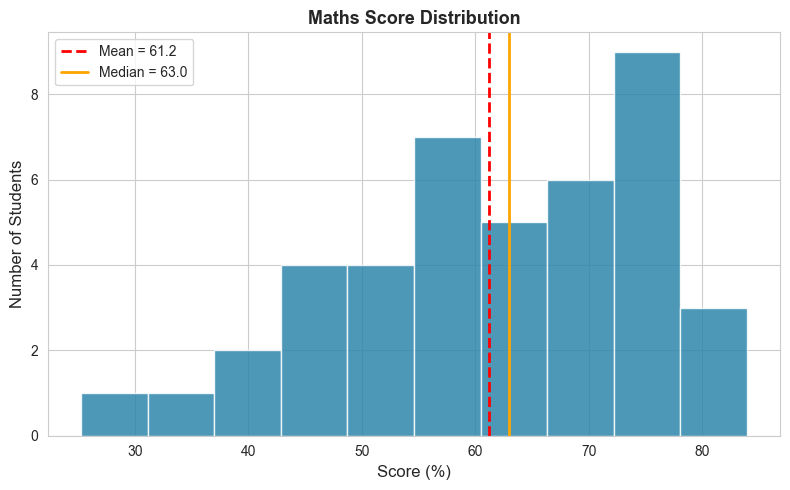

In [30]:
# Histogram of maths scores with key statistics marked
plt.figure(figsize=(8, 5))
plt.hist(maths, bins=10, color='#2E86AB', edgecolor='white', alpha=0.85)

# Mark the mean and median as vertical lines for comparison
plt.axvline(maths.mean(),          color='red',    linestyle='--', linewidth=2,
            label=f'Mean = {maths.mean():.1f}')
plt.axvline(np.median(maths),      color='orange', linestyle='-',  linewidth=2,
            label=f'Median = {np.median(maths):.1f}')

plt.title('Maths Score Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Score (%)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

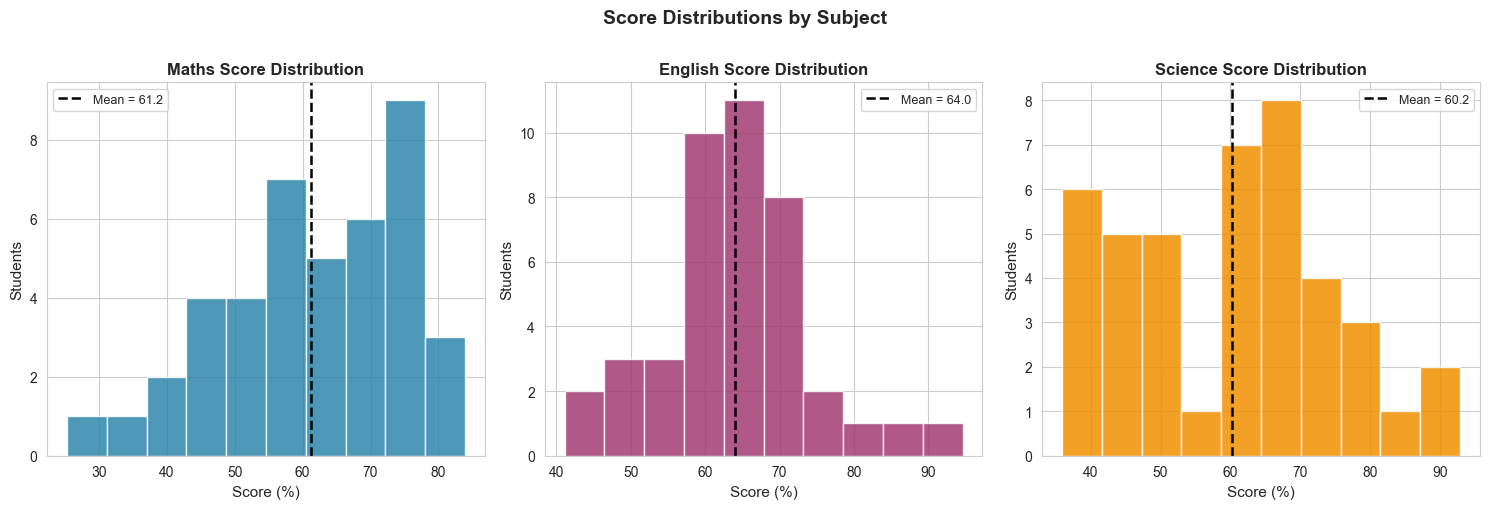

In [31]:
# Side-by-side histograms for all three subjects
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
subject_arrays = [maths, english, science]
colours        = ['#2E86AB', '#A23B72', '#F18F01']

for ax, arr, subj, col in zip(axes, subject_arrays, subjects, colours):
    ax.hist(arr, bins=10, color=col, edgecolor='white', alpha=0.85)
    # Add mean line to each subplot
    ax.axvline(arr.mean(), color='black', linestyle='--', linewidth=1.8,
               label=f'Mean = {arr.mean():.1f}')
    ax.set_title(f'{subj} Score Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Score (%)', fontsize=11)
    ax.set_ylabel('Students', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Score Distributions by Subject', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# plotly 

## Summary - NumPy Aggregation Reference

| Function | What it computes | School use |
|----------|-----------------|------------|
| `arr.sum()` | Total of all values | Sum of all scores |
| `arr.mean()` | Average | Average score per subject |
| `arr.std()` | Standard deviation (spread) | How spread out scores are |
| `arr.min()` | Smallest value | Lowest scoring student |
| `arr.max()` | Largest value | Highest scoring student |
| `arr.argmin()` | Index of the minimum | Row number of lowest scorer |
| `arr.argmax()` | Index of the maximum | Row number of highest scorer |
| `np.median(arr)` | Middle value | Score at the 50th percentile |
| `np.percentile(arr, q)` | Value at the q-th percentile | Grade boundaries |

### `axis` argument

| `axis` | Direction | School meaning |
|--------|----------|----------------|
| None (default) | Entire array | One value for all students and subjects |
| `axis=0` | Down the rows | One value **per subject** |
| `axis=1` | Across the columns | One value **per student** |

### Key rule
**Always use NumPy aggregations (`np.sum`, `arr.min()` etc.) on NumPy arrays — never Python's built-in `sum`, `min`, `max`.** NumPy versions run in compiled code and are orders of magnitude faster on large datasets.